In [1]:
import sys
sys.path.append('../')
from matplotlib import pyplot as plt
import numpy as np

from ventilation_layer import heat_transfer_coefficient as htc
from ventilation_layer import reference_natural_convection as rnc

# 対流熱伝達率の検証（無風）

In [2]:
# 温度条件
theta_1 = 20.0
theta_2 = np.arange(1, 21) * 1.0
print(theta_2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


In [3]:
# 通気層高さ、厚さは固定
l_h = 3.0
l_d = 0.03

In [4]:
# theta_1: surface temp.
# theta_2: array temp.
theta_f = (theta_1 + theta_2) / 2.0

In [5]:
# 垂直の場合
# 最新建築環境工学第4版
takeda_method_v = rnc.calc_takeda_method(delta_t=abs(theta_1 - theta_f), direction="v")

# 空調便覧第14版
shase_handbook_v_out = np.vectorize(rnc.calc_shase_handbook_method)(tw=theta_1, tf=theta_f, d=l_h, direction="v")
shase_handbook_v_in = np.vectorize(rnc.calc_shase_handbook_method)(tw=theta_2, tf=theta_f, d=l_h, direction="v")

# 建築設備基礎
kimura_v_out = np.vectorize(rnc.calc_kimura_method)(tw=theta_1, tf=theta_f, d=l_h, direction="v")
kimura_v_in = np.vectorize(rnc.calc_kimura_method)(tw=theta_2, tf=theta_f, d=l_h, direction="v")

# ASHRAE Handbook Fundamentals 2013
ashrae_handbook_v_out = np.vectorize(rnc.calc_ashrae_handbook_method)(tw=theta_1, tf=theta_f, L=l_h, direction="v")
ashrae_handbook_v_in = np.vectorize(rnc.calc_ashrae_handbook_method)(tw=theta_2, tf=theta_f, L=l_h, direction="v")

# 機械学会　伝熱工学資料改訂第5版
jsme_databook_v = np.vectorize(rnc.calc_jsme_databook)(tw=theta_1, tf=theta_f, L=l_h, b=l_d)

# 赤坂の方法
akasaka_v = np.vectorize(htc.get_h_cv)(calc_mode="detailed", v_a=0.0, theta_1=theta_1, theta_2=theta_2, angle=90.0, l_h=l_h, l_d=l_d)


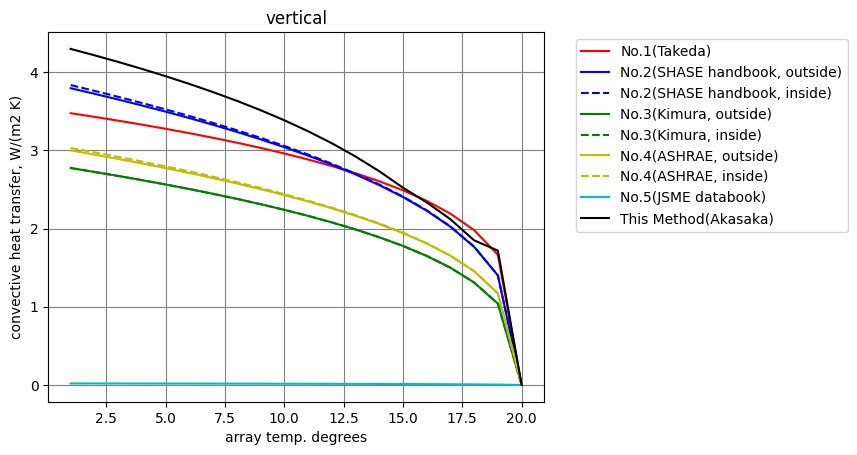

In [6]:
# グラフの描画
fig1 = plt.figure()
ax1 = fig1.subplots()

ax1.set_xlabel('array temp. degrees')
ax1.set_ylabel('convective heat transfer, W/(m2 K)')

plt.grid(which='major', color='gray', linestyle='-')
plt.grid(which='minor', color='gray', linestyle='-')

plt.plot(theta_2, takeda_method_v, linestyle='solid', color='r', label='No.1(Takeda)')
plt.plot(theta_2, shase_handbook_v_out, linestyle='solid', color='b', label='No.2(SHASE handbook, outside)')
plt.plot(theta_2, shase_handbook_v_in, linestyle='dashed', color='b', label='No.2(SHASE handbook, inside)')
plt.plot(theta_2, kimura_v_out, linestyle='solid', color='g', label='No.3(Kimura, outside)')
plt.plot(theta_2, kimura_v_in, linestyle='dashed', color='g', label='No.3(Kimura, inside)')
plt.plot(theta_2, ashrae_handbook_v_out, linestyle='solid', color='y', label='No.4(ASHRAE, outside)')
plt.plot(theta_2, ashrae_handbook_v_in, linestyle='dashed', color='y', label='No.4(ASHRAE, inside)')
plt.plot(theta_2, jsme_databook_v, linestyle='solid', color='c', label='No.5(JSME databook)')
plt.plot(theta_2, akasaka_v, linestyle='solid', color='k', label='This Method(Akasaka)')

plt.title('vertical')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()